In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml

print("Téléchargement")
credit = fetch_openml(name='default-of-credit-card-clients', version=1, as_frame=True, parser='auto')
df = credit.frame 

df = df.rename(columns={df.columns[-1]: 'DEFAUT'})
df['DEFAUT'] = pd.to_numeric(df['DEFAUT'])

print("5 premières lignes")
display(df.head())


Téléchargement
5 premières lignes


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,...,x15,x16,x17,x18,x19,x20,x21,x22,x23,DEFAUT
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [5]:
noms_colonnes = [
    'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'DEFAUT'
]
df.columns = noms_colonnes 

print("Tableau avec vrai nom dataset")
display(df.head())


Tableau avec vrai nom dataset


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAUT
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


Répartition des clients
Bons payeurs (0) : 77.9 %
En défaut (1) : 22.1 %


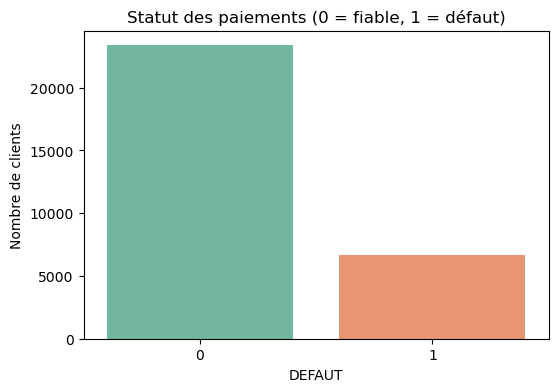

In [8]:
repartition = df['DEFAUT'].value_counts(normalize=True) * 100
print("Répartition des clients")
print(f"Bons payeurs (0) : {repartition[0]:.1f} %")
print(f"En défaut (1) : {repartition[1]:.1f} %")

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='DEFAUT', hue='DEFAUT', palette='Set2', legend=False)
plt.title('Statut des paiements (0 = fiable, 1 = défaut)', fontsize=12)
plt.ylabel('Nombre de clients')
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X = df.drop(columns=['DEFAUT'])
y = df['DEFAUT']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modele_log = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
modele_log.fit(X_train_scaled, y_train)

print("l'algorithme a terminé d'apprendre sur les profils clients")


l'algorithme a terminé d'apprendre sur les profils clients


Rapport de classification
              precision    recall  f1-score   support

           0       0.87      0.70      0.77      4673
           1       0.37      0.62      0.46      1327

    accuracy                           0.68      6000
   macro avg       0.62      0.66      0.62      6000
weighted avg       0.76      0.68      0.70      6000

Score AUC (capacité de déparation) : 0.708



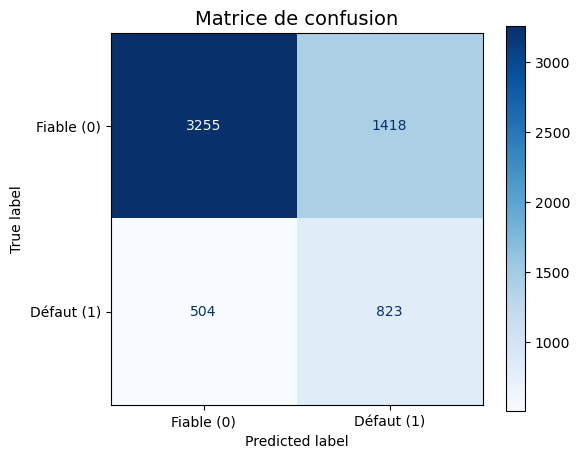

In [13]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay

y_pred = modele_log.predict(X_test_scaled)
y_pred_proba = modele_log.predict_proba(X_test_scaled)[:, 1]

print("Rapport de classification")
print(classification_report(y_test, y_pred))

auc = roc_auc_score(y_test, y_pred_proba)
print(f"Score AUC (capacité de déparation) : {auc:.3f}\n")

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fiable (0)', 'Défaut (1)'])
disp.plot(cmap='Blues', values_format='d', ax=ax)
plt.title('Matrice de confusion', fontsize=14)
plt.show()

In [ ]:
coefficients = pd.DataFrame({
    'Critère' : X.columns, 
    'Impact_risque': modele_log.coef_[0]
}).sort_values(by='Impact_risque', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=coefficients, x='Impact_risque', y='Critère', hue='Critère', palette='coolwarm_r', legend=False)
plt.axvline(x=0, color='black', linestyle='--')
plt.title("Qu'est ce qui déclenche l'alerte de défaut de paiement ?", fontsize=14)
plt.xlabel("<- Diminue le risque (sécurité) | Augemente le risque (danger) ->")
plt.ylabel("Caractéristiques du client")
plt.show()

Le modèle de régression logistique offre une base solide pour évaluer le risque client, avec un score AUC de 0,71. En forçant l'algorithme à prêter attention à la classe minoritaire, j'ai privilégié la détection proactive des défauts réels.

Voici les principaux enseignements pour la stratégie de la banque :

* L'historique de paiement très récent (notamment la variable `PAY_0`) est le signal d'alerte le plus critique. Un incident le mois précédent est un indicateur de risque bien plus fort que l'âge ou le niveau d'études.
* À l'inverse, une limite de crédit élevée (`LIMIT_BAL`) tire le risque vers le bas. Cela valide que ces plafonds sont accordés aux clients dont la solvabilité est déjà éprouvée.
* Le modèle ne donne pas qu'une réponse binaire, il fournit une probabilité de défaut. L'équipe métier peut s'en servir pour automatiser des actions :
  * **Score > 80 % :** Blocage préventif de la carte.
  * **Score entre 50 % et 80 % :** Alerte levée pour qu'un conseiller contacte le client.
  * **Score < 50 % :** Client considéré comme fiable.